In [1]:
import ojas_feb0126_find_best_run as fbr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
root_path = "/mnt/home/donti-group-shared/ojas/pfdelta/runs/gen_feb0126"

cases = ["case14", "case30", "case57", "case118", "case500"]
combined_cases = ["case14_30_118", "case30_57_118", "case30_57_500", "case57_118_500"]
tasks = ["task31", "task32", "task33", "task34"]
models = ["graphconv", "powerflownet"]
error_key = "PBL Mean"

In [3]:
results = {}

def add_result(best_runs, task, model, case):
    if results.get(task) is None:
        results[task] = {}
    if results[task].get(model) is None:
        results[task][model] = {}
        
    results[task][model][case] = best_runs

In [4]:
for model in models:
    # print("---------------TASK 1")
    for task in [tasks[0]]:
        for case in cases:
            folder = f"{root_path}/{task}/{model}/{case}"
            best_runs = fbr.find_best_run(folder, error_key)
            add_result(best_runs, task, model, case)

    # print("---------------TASK 2 AND 3")
    for task in [tasks[1], tasks[2]]:
        case = "case14_30_57" if task == tasks[1] else "case118_500"
        folder = f"{root_path}/{task}/{model}/"
        best_runs = fbr.find_best_run(folder, error_key)
        add_result(best_runs, task, model, case)

    for task in [tasks[3]]:
        for case in combined_cases:
            folder = f"{root_path}/{task}/{model}/{case}"
            best_runs = fbr.find_best_run(folder, error_key)
            add_result(best_runs, task, model, case)

/mnt/home/donti-group-shared/ojas/pfdelta/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [5]:
ROWS = ["14", "30", "57", "118", "500", "14_30_57", "118_500", "14_30_118", "30_57_118", "30_57_500", "57_118_500"]
COLS = ROWS.copy()[:5]

row_to_cols = {}

for row in ROWS:
    row_to_cols[row] = [COLS]
    
row_idx = {r: i for i, r in enumerate(ROWS)}
col_idx = {c: j for j, c in enumerate(COLS)}

In [6]:
def get_row_col(train_case, test_case):
    if test_case.startswith("case"):
        test_case = test_case[4:]
    if train_case.startswith("case"):
        train_case = train_case[4:]
    return [row_idx[train_case], col_idx[test_case]]

In [7]:
graphconv_means = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
graphconv_stds = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
powerflownet_means = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)
powerflownet_stds = np.full((len(ROWS), len(COLS)), np.nan, dtype=float)

In [16]:
for task, task_values in results.items():
    for model, model_values in task_values.items():
        # print(f"Task {task}: {model_values.items()}")
        for train_case, train_values in model_values.items():
            # print(train_values)
            summaries = train_values[4]

            # print(summaries)

            if summaries is None:
                continue

            mean_err_per_test_case_per_seed = {
                "case14": [],
                "case30": [],
                "case57": [],
                "case118": [],
                "case500": [],
            }

            # go through all of the seeds
            # for each seed, get the summary
            for summary in summaries:
                if summary is None:
                    [mean_err_per_test_case_per_seed[i].append(np.nan) for i in cases]
                    continue

                val = summary["val"]
                
                print(val)
                # print(cases)

                # go through all of the validation sets
                # skip the first one (its a duplicate of the second one for config reasons)
                start_index = 1
                # mistake in this config where theres an extra duplicate val, so skip the first two instead of just the first one
                if (task == "task34") and (model == "graphconv"):
                    start_index = 2
                    
                # take the pbl mean, put it into the appropriate spot in the list
                # depending on the test_case
                # we shoud have one entry per test case per seed
                for i in range(start_index, len(val)):
                    print(task)
                    print(model)
                    print(start_index)
                    print(len(val))
                    print(i)
                    print(cases)
                    test_case = cases[i - start_index]
                    val_dict = val[i]
                    err = val_dict[error_key]

                    mean_err_per_test_case_per_seed[test_case].append(err)

            # print("Processing:", task, model, train_case)
            # print(mean_err_per_test_case_per_seed)

            for test_case in mean_err_per_test_case_per_seed.keys():
                # calculate mean and std for the err for each test_case
                errs = mean_err_per_test_case_per_seed[test_case]
                mean_err = np.mean(errs)
                std_err = np.std(errs)
                
                # print(f"\t{train_case}, {test_case}", end=": ")

                # these should be the same
                # best_err_mean = train_values[2]
                # best_err_std = train_values[3]
                # print("this case best err mean std: ", best_err_mean, best_err_std)
                # print("computed case mean std: ", mean_err, std_err)
                
                r, c = get_row_col(train_case, test_case)
                # print(r, c)
                # print(mean_err)

                if model == "graphconv":
                    graphconv_means[r, c] = mean_err
                    graphconv_stds[r, c] = std_err
                elif model == "powerflownet":
                    powerflownet_means[r, c] = mean_err
                    powerflownet_stds[r, c] = std_err

[{'Masked MSE': 0.11289699375629425, 'Masked MSE, reg.': 0.11344957531375044, 'MSELoss': 0.038000718241228776, 'PBL Mean': 0.24143992487122032, 'PBL Max': 3.02486246473649, 'PBL L2': 1.205964561069713}, {'Masked MSE': 0.11289699375629425, 'Masked MSE, reg.': 0.11344957531375044, 'MSELoss': 0.03800071810974794, 'PBL Mean': 0.24143992522183585, 'PBL Max': 3.02486246473649, 'PBL L2': 1.2059645631734062}, {'Masked MSE': 0.9719689768903396, 'Masked MSE, reg.': 1.1201611413675197, 'MSELoss': 0.4227844224256628, 'PBL Mean': 1.1283092344508452, 'PBL Max': 10.303076082117418, 'PBL L2': 9.4320177414838}, {'Masked MSE': 5.736920928955078, 'Masked MSE, reg.': 6.428180879705092, 'MSELoss': 2.373146951899809, 'PBL Mean': 6.037014703189626, 'PBL Max': 82.79916767793543, 'PBL L2': 77.8700901704676}, {'Masked MSE': 83.27511381261489, 'Masked MSE, reg.': 125.32391186882468, 'MSELoss': 55.7909028894761, 'PBL Mean': 21.758265596277575, 'PBL Max': 2071.1322021484375, 'PBL L2': 495.3709142348346}, {'Masked 

In [17]:
def plot_grouped_bar_chart(means: np.ndarray, stds: np.ndarray, model_name: str):
    n_test, n_train = means.shape
    x = np.arange(n_test)  # group positions
    bar_width = 0.8 / n_train  # width of each bar

    fig, ax = plt.subplots(figsize=(14, 5.5))
    # "Set3" or "tab20"
    cmap = plt.colormaps["tab20"]

    for i in range(n_train):
        offset = (i - n_train / 2) * bar_width + bar_width / 2

        # length n_test
        y = means[:, i]
        yerr = stds[:, i]

        # If NaNs appear in means or stds, bar() will quietly skip drawing those bars
        ax.bar(
            x + offset,
            y,
            width=bar_width,
            yerr=yerr,
            label=f"Case {ROWS[i]}",
            capsize=3,
            linewidth=0.8,
            edgecolor="black",
            alpha=0.95,
            color=cmap(i),
            error_kw=dict(elinewidth=1, capsize=3, capthick=1),
        )

    # --- cosmetics ---

    title_size = 20
    label_size = 16
    tick_size = 14
    legend_title_size = 14
    legend_text_size = 12

    # titles & labels
    ax.set_title(
        f"{model_name}: Performance on different test cases across different train cases",
        pad=10,
        fontsize=title_size,
    )
    ax.set_ylabel("Mean PBL (+/- 1 SD) (log)", fontsize=label_size)
    ax.set_xlabel("Test Case", fontsize=label_size)

    # x ticks
    ax.set_xticks(x, [f"Case {COLS[i]}" for i in range(n_test)], fontsize=tick_size)

    # log y with helpful grid
    ax.set_yscale("log")
    
    ax.grid(True, which="both", axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

    # de-clutter spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        # loc="upper right",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Trained On",
        title_fontsize=legend_title_size,
        fontsize=legend_text_size,
    )
    
    # catch error in case there is no data
    # and log doesn't woork
    try:
        fig.tight_layout()
    except ValueError:
        ax.set_yscale("linear")
    plt.show()

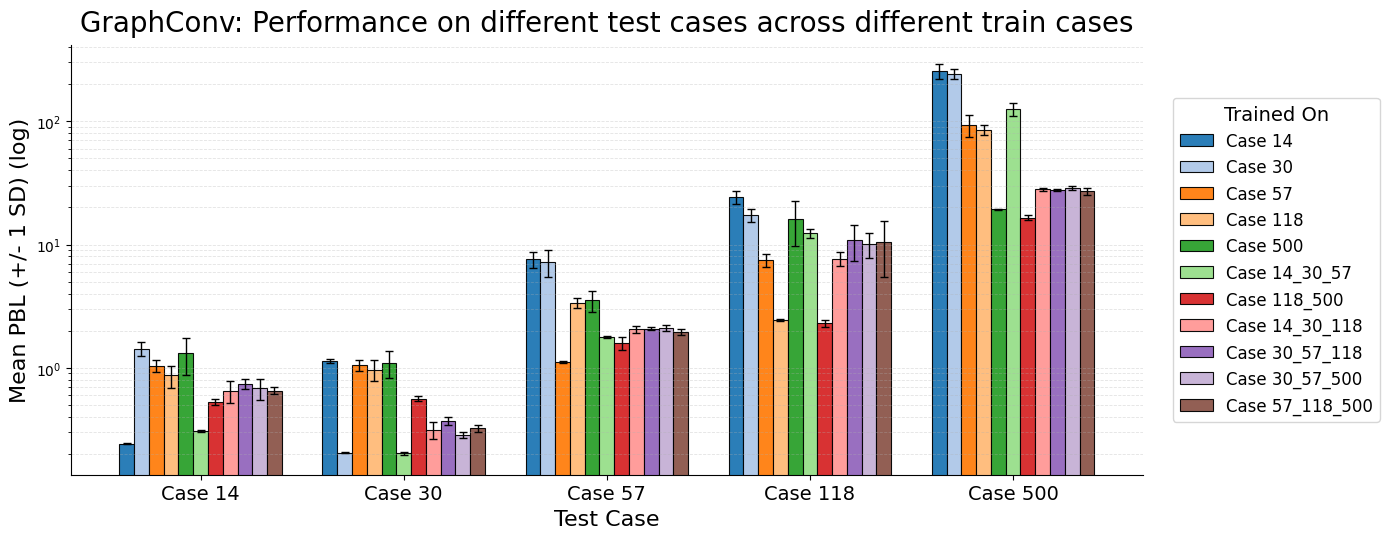

In [18]:
means = graphconv_means.T
stds = graphconv_stds.T

plot_grouped_bar_chart(means, stds, "GraphConv")

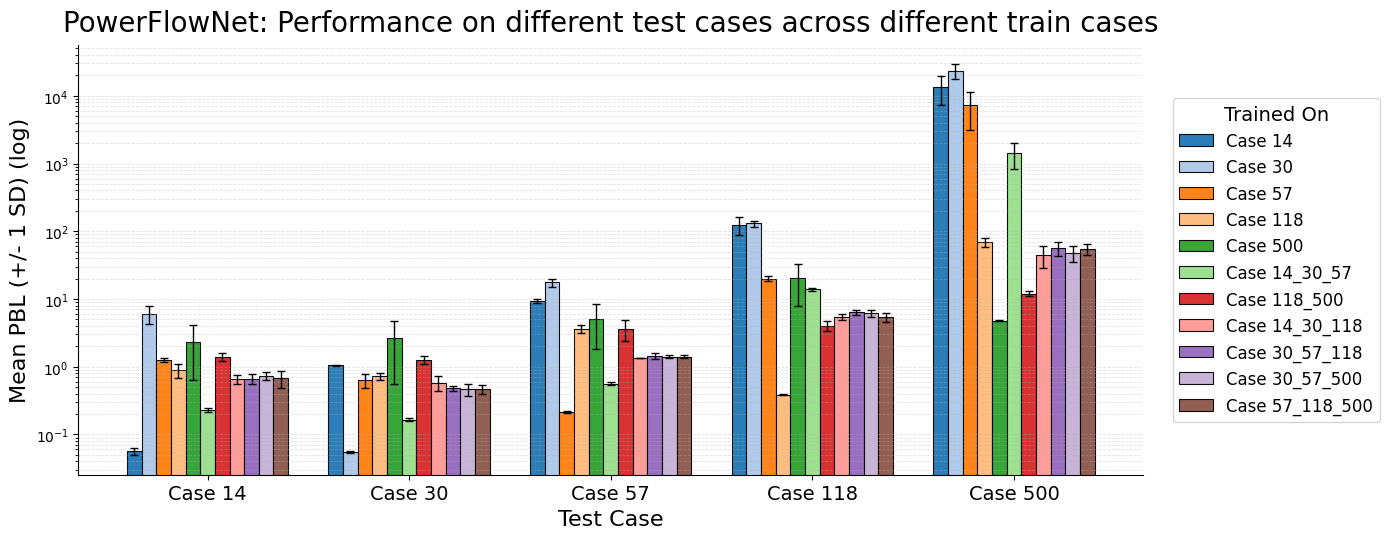

In [19]:
means = powerflownet_means.T
stds = powerflownet_stds.T

plot_grouped_bar_chart(means, stds, "PowerFlowNet")